# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [56]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [57]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [58]:
# read the data
df = pd.read_csv("SuperKart.csv")


In [59]:
data = df.copy()

# **Data Overview**

In [60]:
# returns the first 5 rows
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [61]:
print('The data has',data.shape[0],'rows and',data.shape[1],'columns')

The data has 8763 rows and 12 columns


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [63]:
unique = data['Product_Sugar_Content'].value_counts()
print(unique)

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


In [64]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [65]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


There are no missing values

# **Exploratory Data Analysis (EDA)**

In [66]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [67]:

# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

## Univariate Analysis

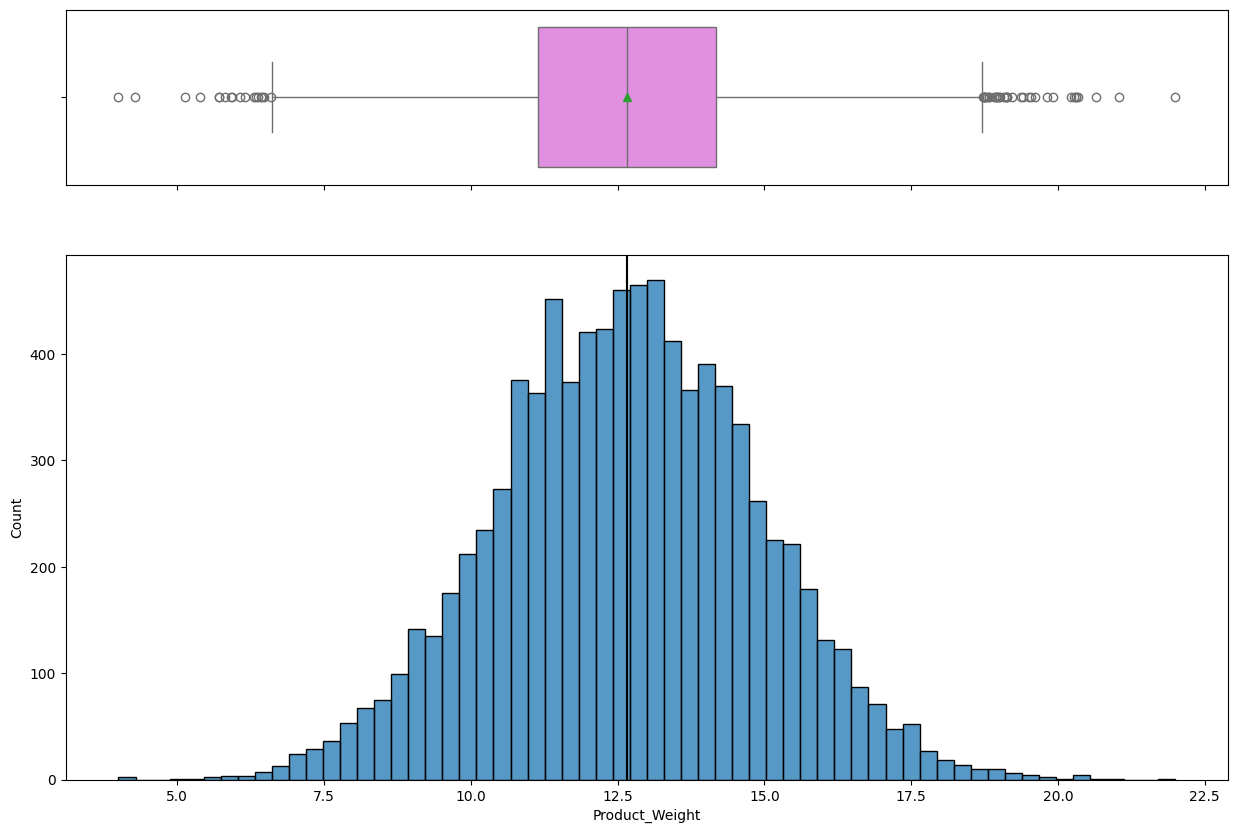

In [68]:
histogram_boxplot(df, "Product_Weight")

median seems to be near 12.5 for product weight

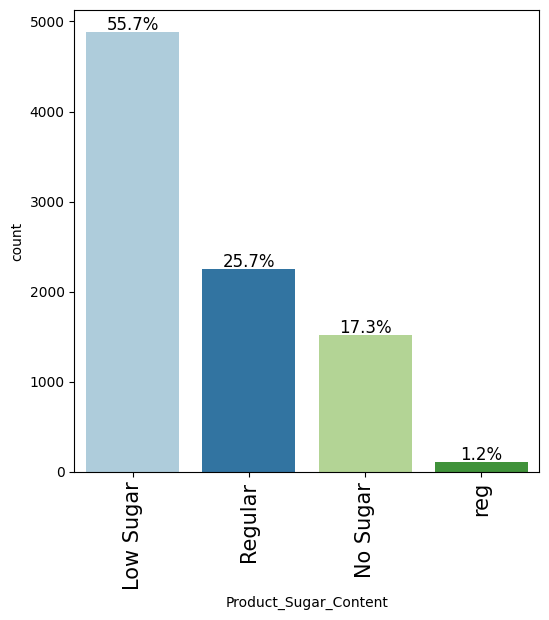

In [69]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

We can see that most of the product type has low sugar content from the above 2 chart

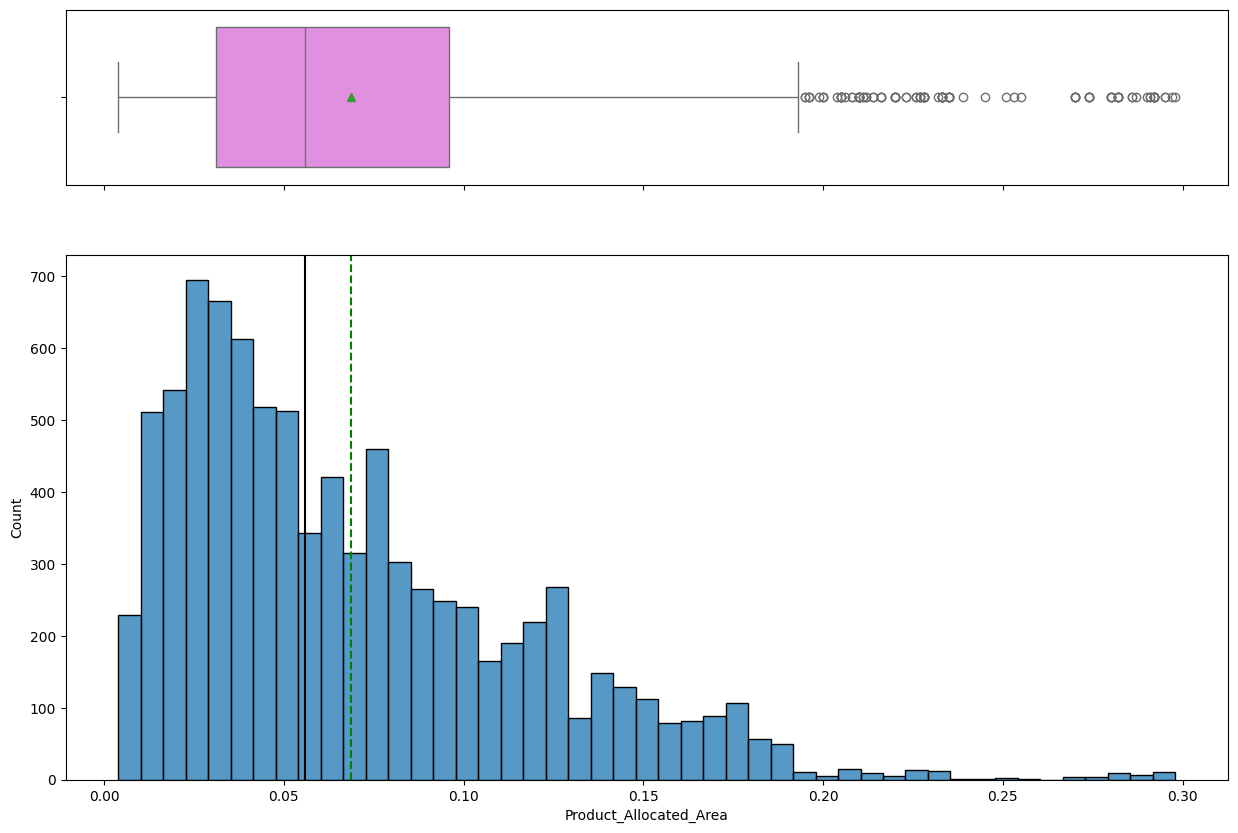

In [70]:
histogram_boxplot(df, "Product_Allocated_Area")

distribution seems to be right skewed

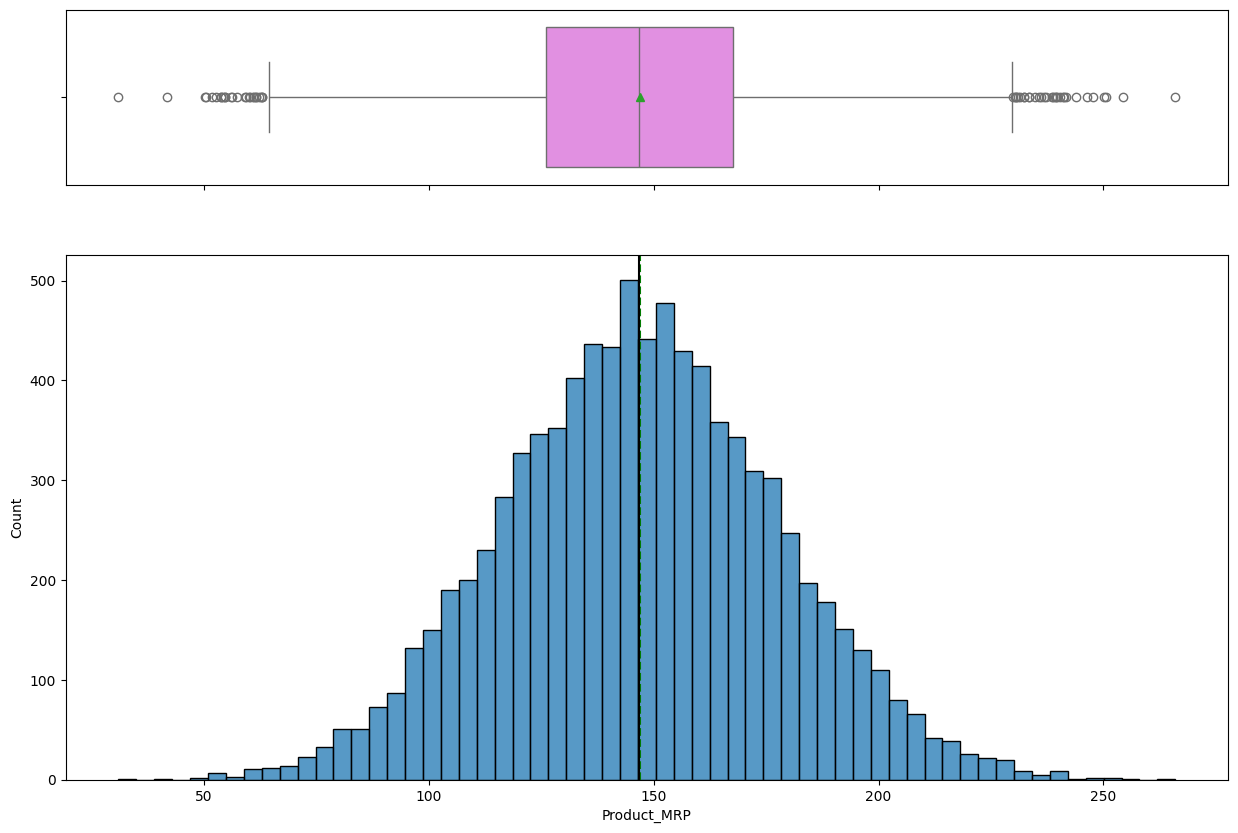

In [71]:
histogram_boxplot(df, "Product_MRP")

MRP seems to have a normal distribution with median at 150

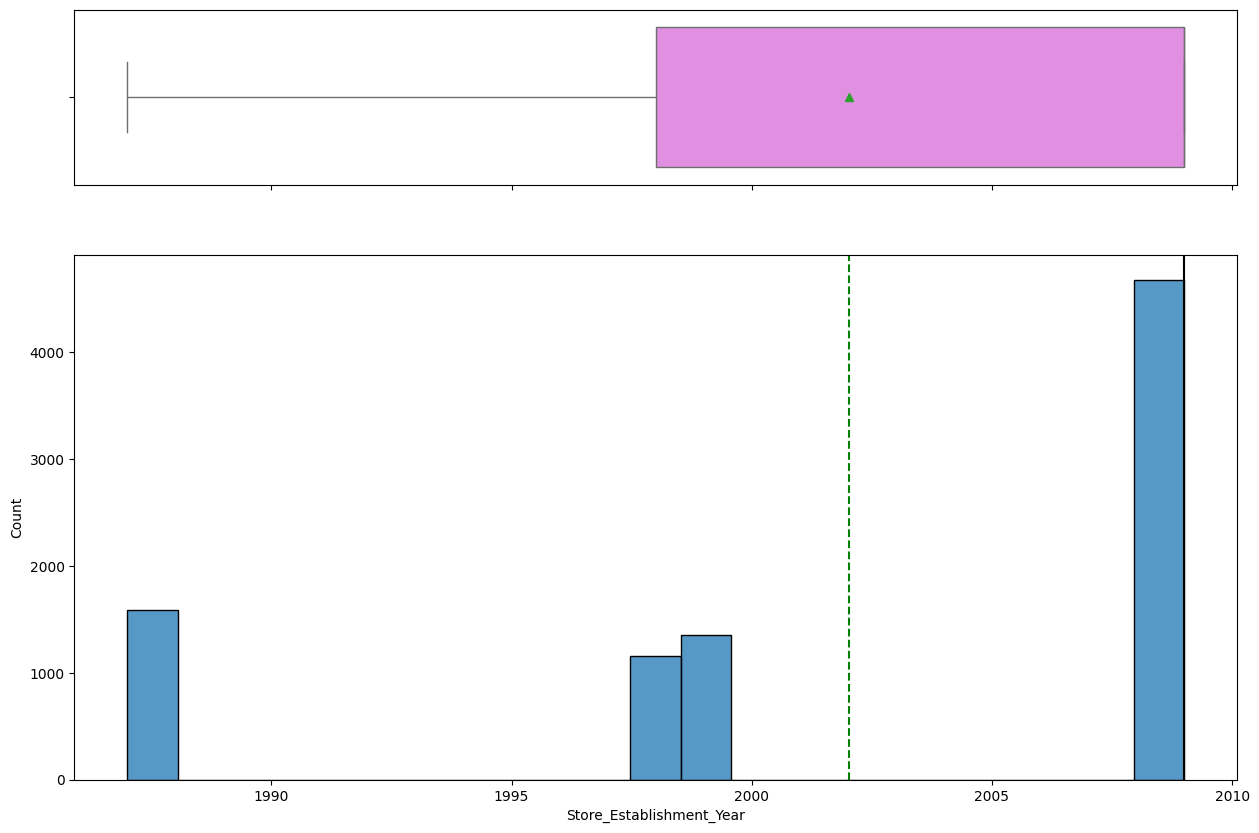

In [72]:
histogram_boxplot(data, "Store_Establishment_Year")

There seems to be more stores that are established recently

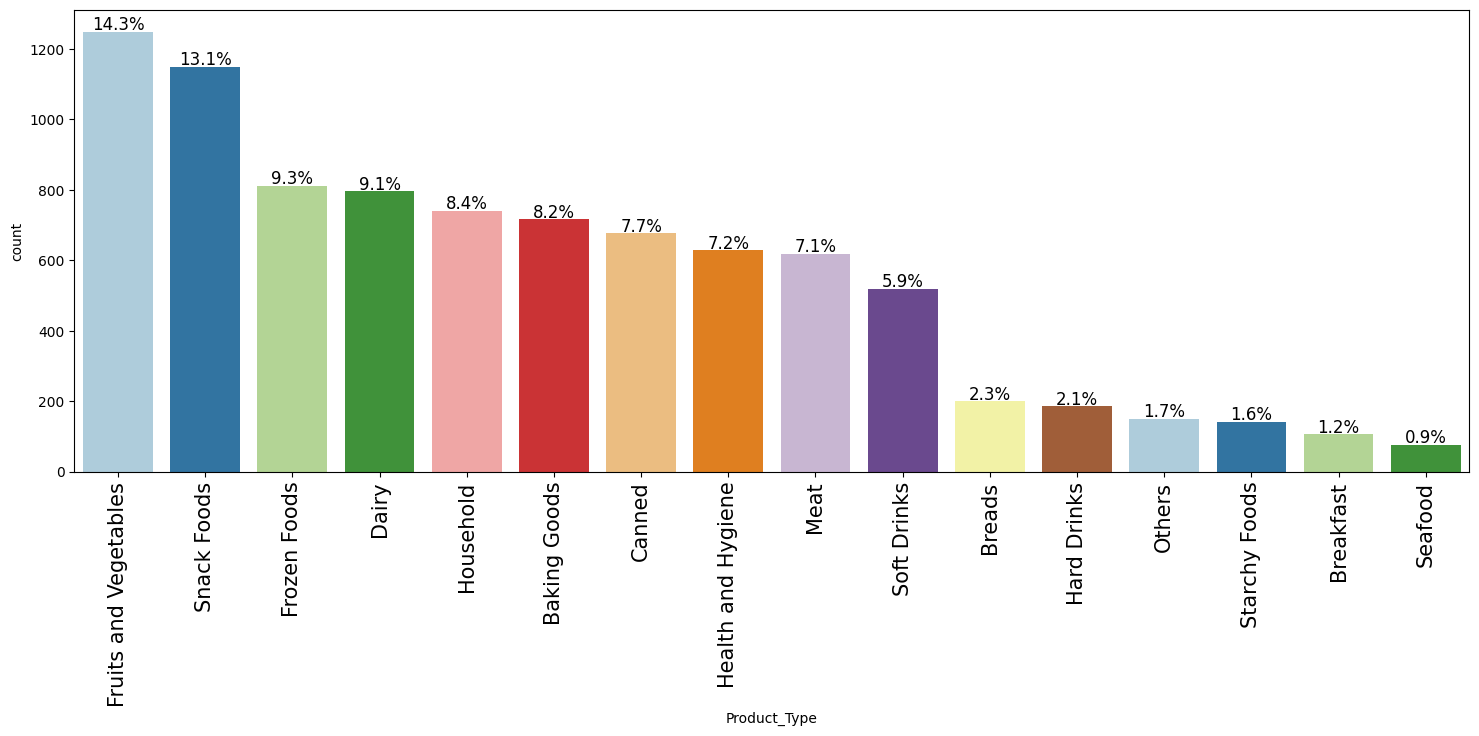

In [73]:
labeled_barplot(df, "Product_Type", perc=True)

Highest number of products are 'Fruits and Vegetables' with 14.3% followed by 'Snack Foods' with 13.1% and son on.  The least type is 'Seafood' with only 0.9%

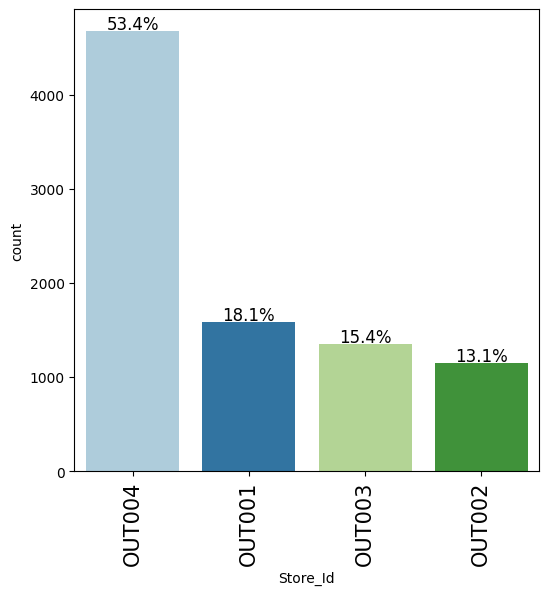

In [74]:
labeled_barplot(data, "Store_Id", perc=True)

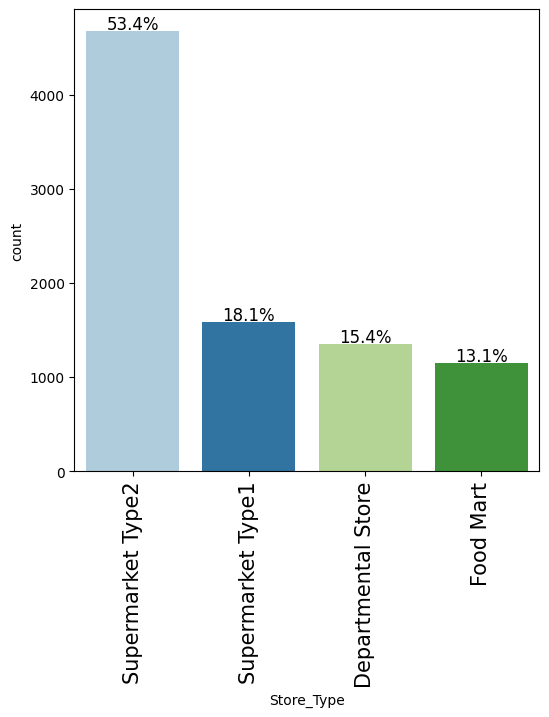

In [75]:
labeled_barplot(data, "Store_Type", perc=True)

The Store_Id and Store_Type columns show similar distributions and top frequencies, suggesting a strong correlation or direct mapping between particular store IDs and their types.
The Store_Id 'OUT004' and Store_Type 'Supermarket Type2' both occur with the same frequency of 53.4%.

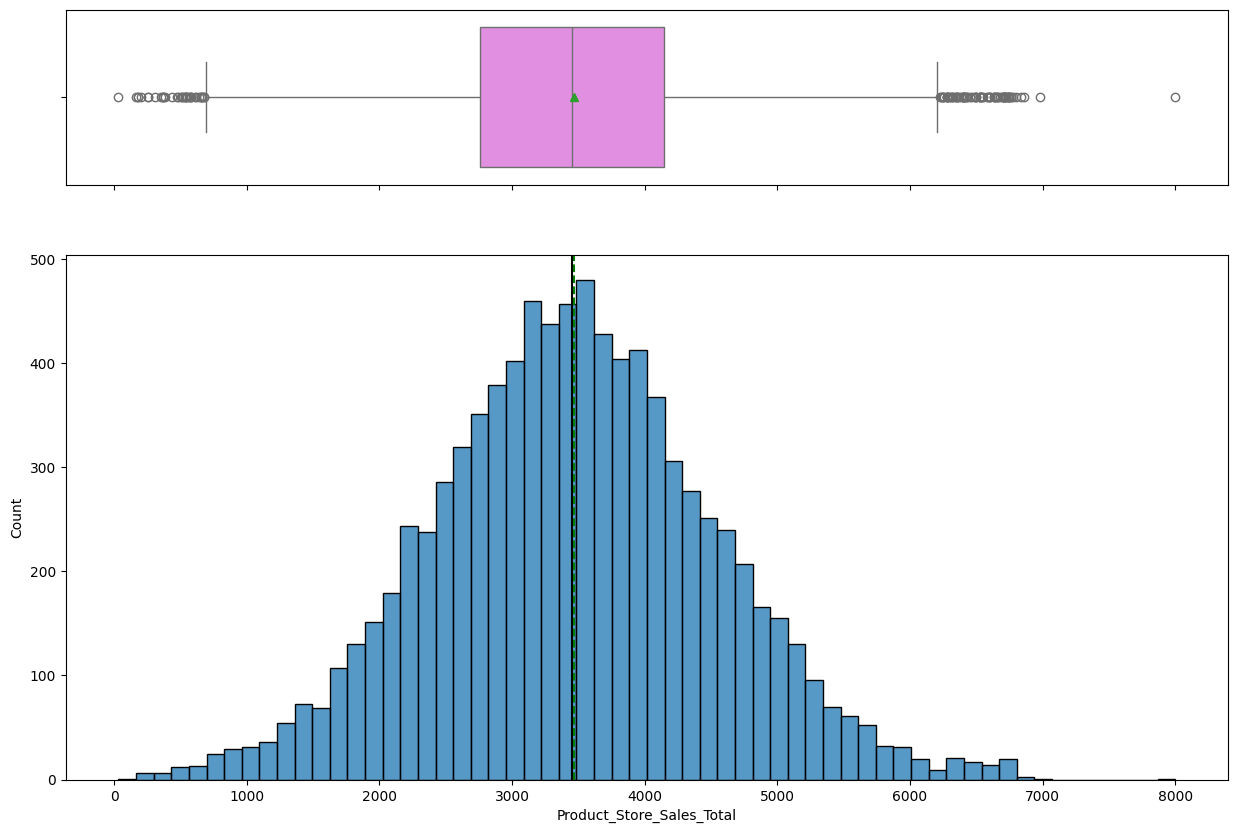

In [76]:
histogram_boxplot(df, "Product_Store_Sales_Total")

The distribution for total sales is normally distributed with a slight tail to the left.

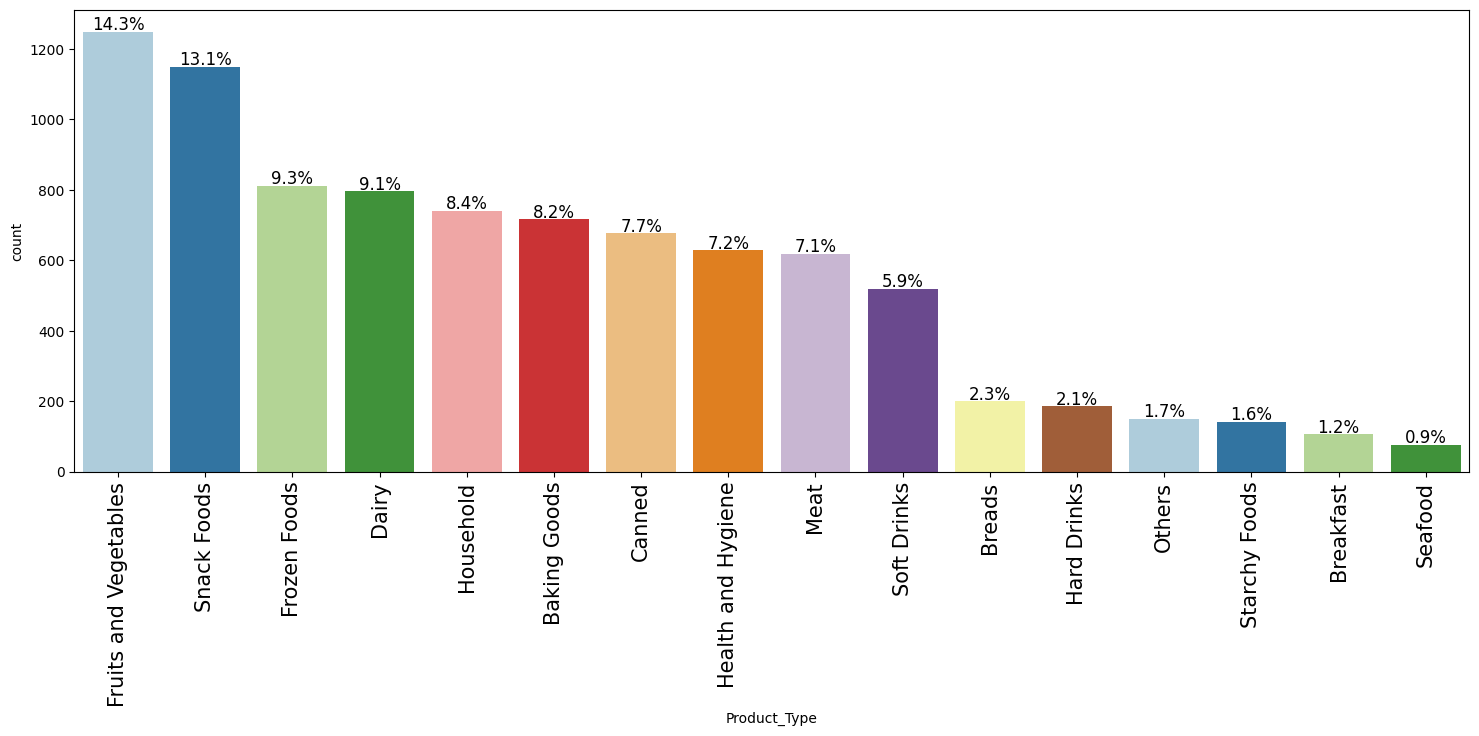

In [77]:
labeled_barplot(data, "Product_Type", perc=True)

More products are sold in stores that are located in Tier 2 cities.

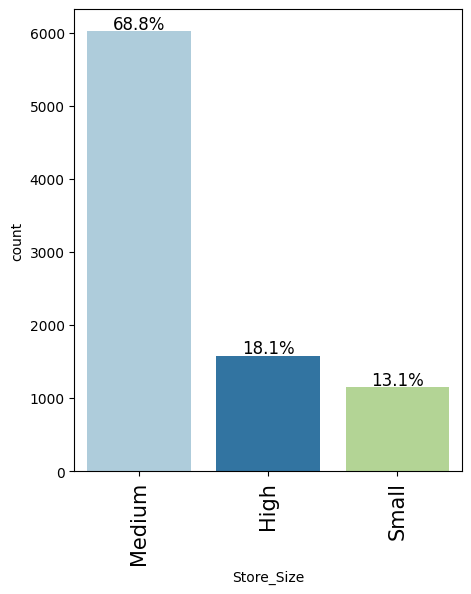

In [78]:
labeled_barplot(data, "Store_Size", perc=True)

Medium-sized stores generated more sales

## Bivariate Analysis

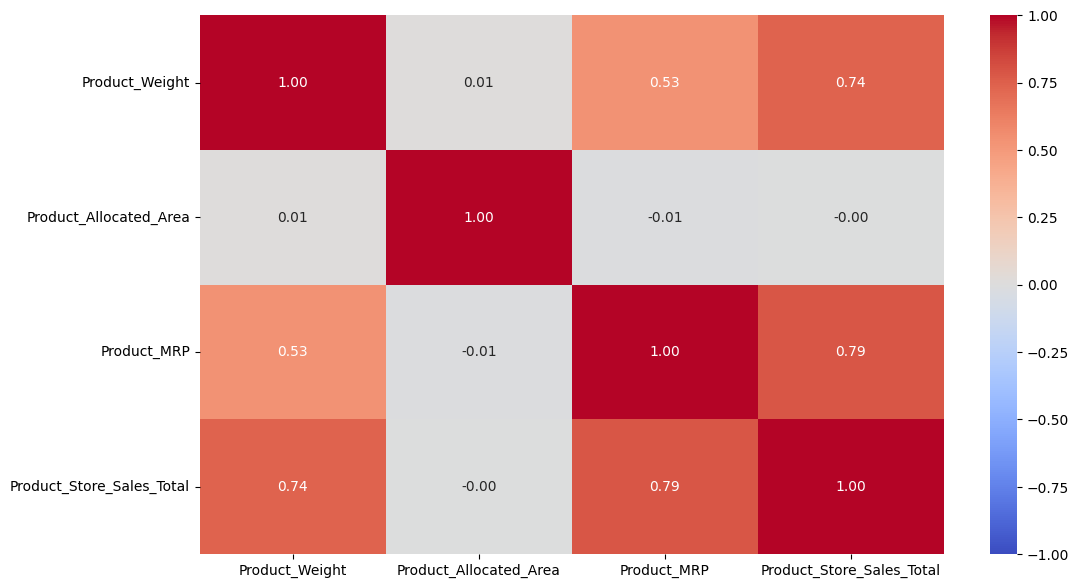

In [79]:
# creating a list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# dropping start and finish year from list of numerical columns as they are not numerical in nature
num_cols.remove("Store_Establishment_Year")

plt.figure(figsize=(12, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm"
)
plt.show()

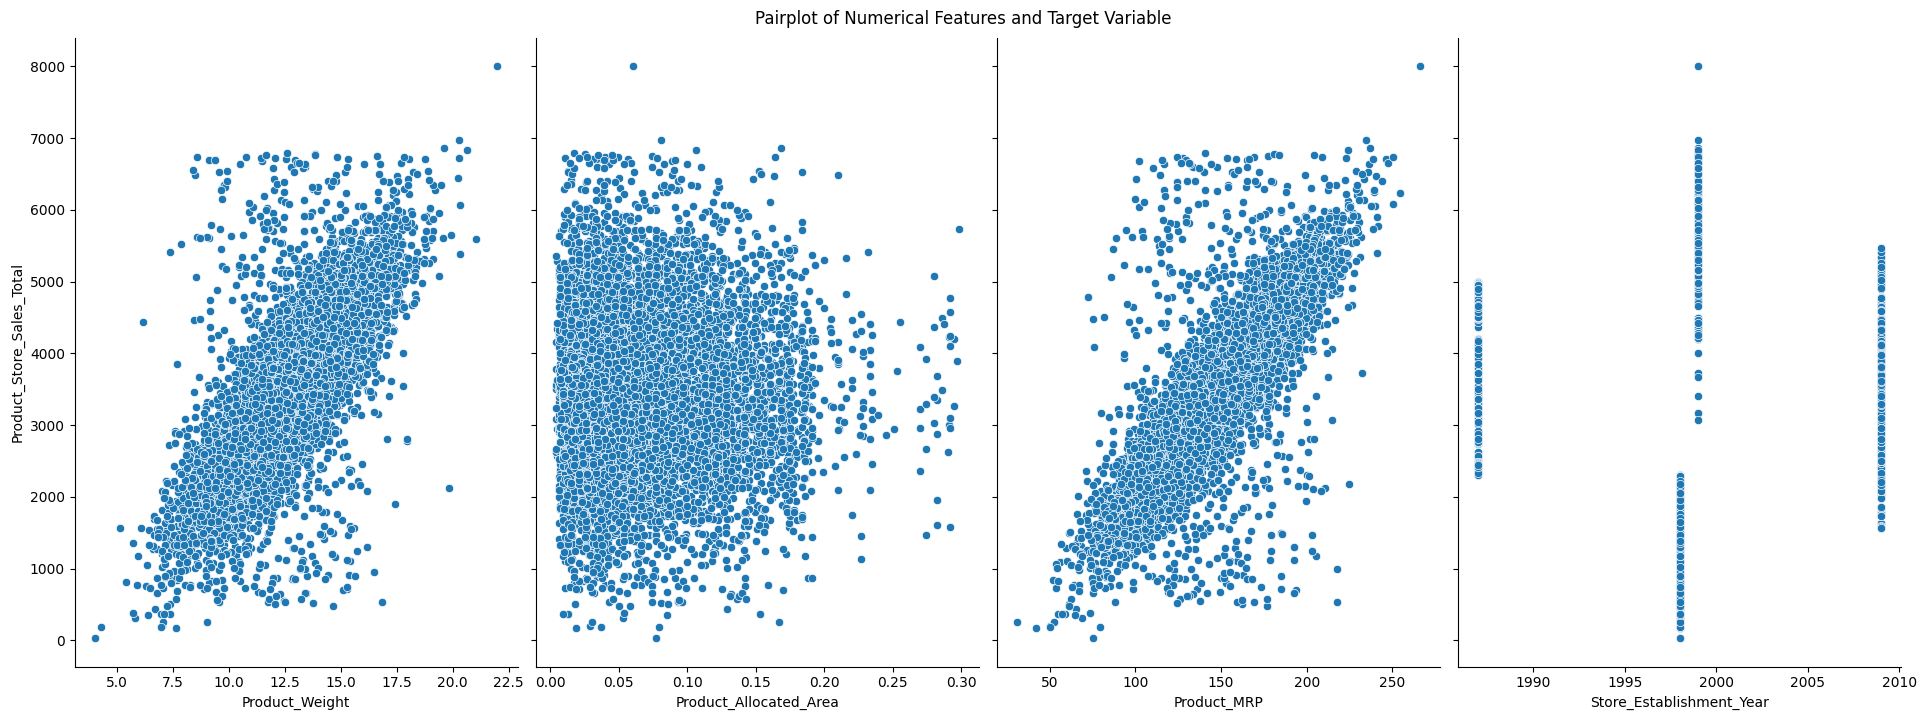

In [80]:
g = sns.pairplot(
    data,
    x_vars=["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year"],
    y_vars=["Product_Store_Sales_Total"],
    height=7,
    aspect=0.7,
)
g.fig.suptitle("Pairplot of Numerical Features and Target Variable", y=1.02)
plt.show()

There is a positive correlation between Product_Store_Sales_Total and Product_Weigh and Product_MRP.

The type of store with the greatest revenue is Supermarket Type2
Overall sales for the best store type is 15427583.43
The location which generates the highest amount of revenue is Tier 2
Revenue for the top location type is 21650696.61


<Figure size 1200x600 with 0 Axes>

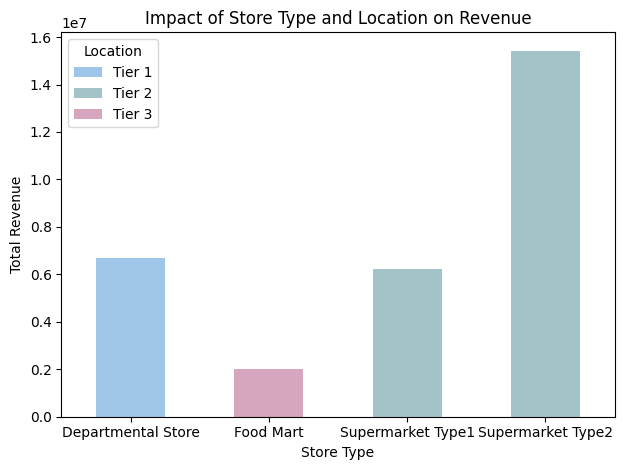

In [81]:

# Group by 'Store_Type' and calculate the average revenue for each store type
store_type_revenue = df.groupby('Store_Type')['Product_Store_Sales_Total'].sum()

# Group by 'Store_Location_City_Type' and calculate the average revenue for each location
location_revenue = df.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].sum()

# Find the store type and location with the highest average revenue
top_store_type = store_type_revenue.idxmax()
top_store_type_revenue = store_type_revenue.max()

top_location = location_revenue.idxmax()
top_location_revenue = location_revenue.max()

print(f"The type of store with the greatest revenue is {top_store_type}")
print(f"Overall sales for the best store type is {top_store_type_revenue:.2f}")

print(f"The location which generates the highest amount of revenue is {top_location}")
print(f"Revenue for the top location type is {top_location_revenue:.2f}")

# Creating a pivot
store_location_revenue = df.pivot_table(index='Store_Type', columns='Store_Location_City_Type', values='Product_Store_Sales_Total', aggfunc='sum')

# Create a bar plot
plt.figure(figsize=(12, 6))
store_location_revenue.plot(kind='bar', stacked=True, color=['#9fc5e8', '#a2c4c9', '#d5a6bd'])
plt.xlabel('Store Type')
plt.ylabel('Total Revenue')
plt.title('Impact of Store Type and Location on Revenue')
plt.xticks(rotation=0)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

As noticed above Supermarket Type 2 is the store type with the highest revenue. The top store type has an overall sales of USD 15427583.43. Tier 2 is the location where the most revenue is made. The revenue for top location type is USD 21650696.61

Product_Type
Fruits and Vegetables    864
Snack Foods              804
Dairy                    590
Frozen Foods             531
Baking Goods             462
Canned                   402
Meat                     377
Soft Drinks              370
Breads                   148
Hard Drinks              128
Starchy Foods             97
Breakfast                 65
Seafood                   47
Name: Product_Store_Sales_Total, dtype: int64


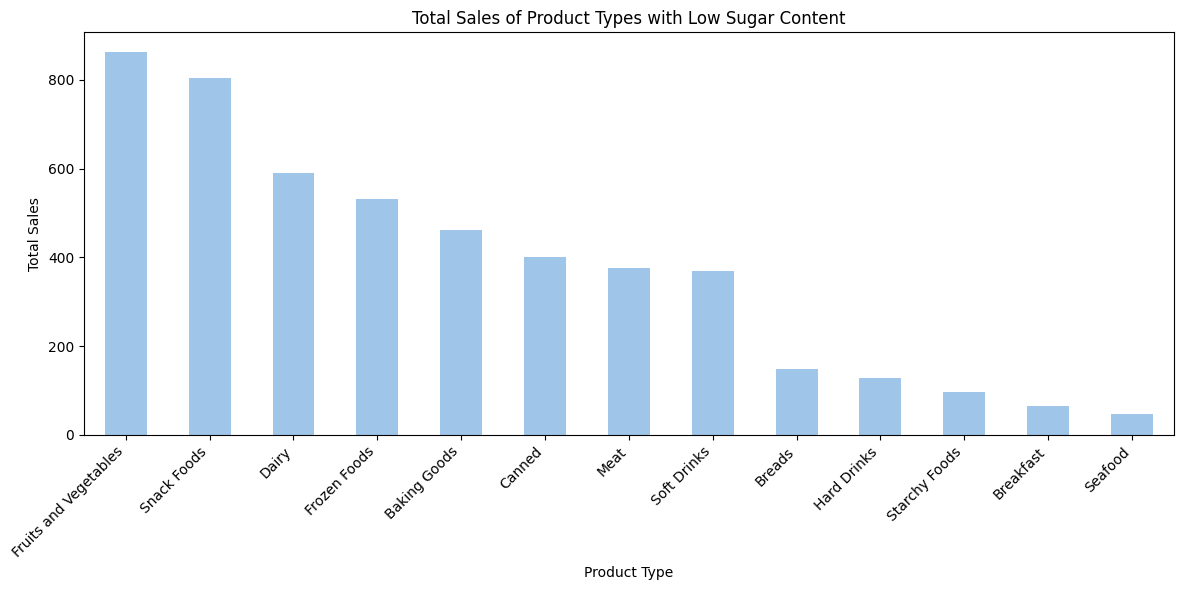

In [82]:

# Filter the DataFrame to rows with 'Product_Sugar_Content' set to 'Low'.
low_sugar_df = df[df['Product_Sugar_Content'] == 'Low Sugar']

# Count the quantity of each product type sold after grouping by 'Product_Type'
items_sold_by_product_type = low_sugar_df.groupby('Product_Type')['Product_Store_Sales_Total'].count().sort_values(ascending=False)

print(items_sold_by_product_type)

# Create a bar plot
plt.figure(figsize=(12, 6))
items_sold_by_product_type.plot(kind='bar', color=['#9fc5e8'])
plt.xlabel('Product Type')
plt.ylabel('Total Sales')
plt.title('Total Sales of Product Types with Low Sugar Content')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Number of items sold in each of the 16 product types that have low sugar content
We can see that The category "Fruits and Vegetables" saw sales of 864 items. 804 items were sold under the "Snack Foods" category etc

Product type sold the most number of times in each store:
Store_Id
OUT001              (OUT001, Snack Foods)
OUT002    (OUT002, Fruits and Vegetables)
OUT003              (OUT003, Snack Foods)
OUT004    (OUT004, Fruits and Vegetables)
Name: Product_Store_Sales_Total, dtype: object

Product type contributing the most to the revenue of each store:
Store_Id
OUT001              (OUT001, Snack Foods)
OUT002    (OUT002, Fruits and Vegetables)
OUT003              (OUT003, Snack Foods)
OUT004    (OUT004, Fruits and Vegetables)
Name: Product_Store_Sales_Total, dtype: object


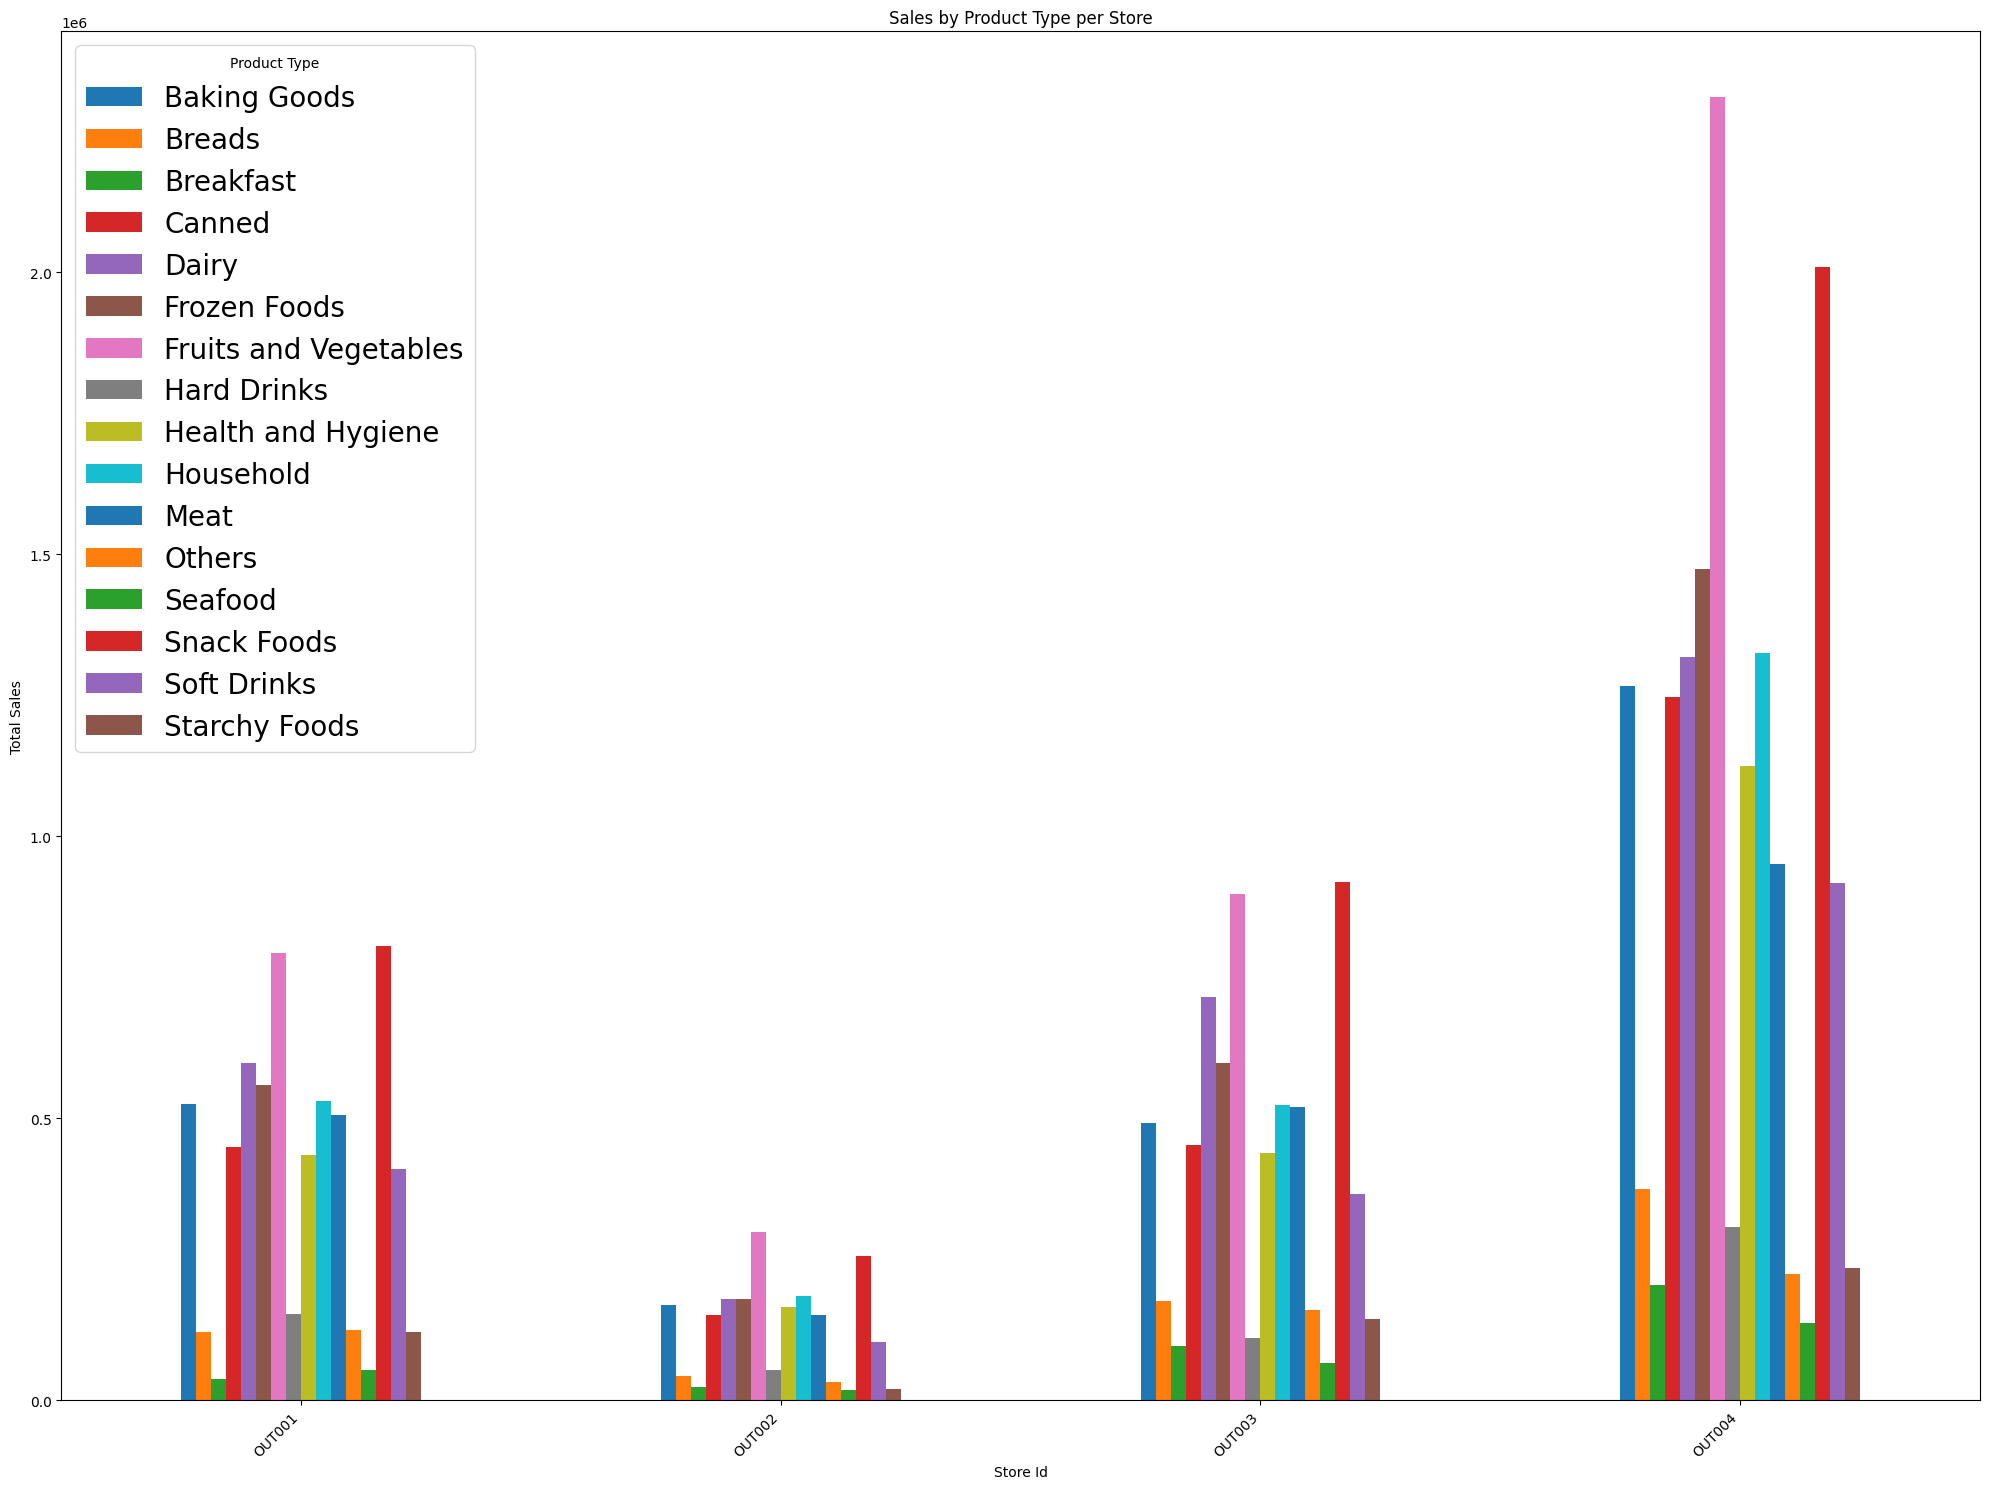

In [83]:
# Group by 'Store_Id' and 'Product_Type' to get the count of sales of each product type sold in each store
product_count_by_store = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].count()

# Find the product type that has been sold the most number of times in each store
max_sold_product_by_store = product_count_by_store.groupby(level='Store_Id').idxmax()

print("Product type sold the most number of times in each store:")
print(max_sold_product_by_store)

# Group by 'Store_Id' and 'Product_Type' to get the total revenue of each product type in each store
revenue_by_product_type = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].sum()

# Find the product type that is contributing the most to the revenue of each store
top_revenue_product_by_store = revenue_by_product_type.groupby(level='Store_Id').idxmax()

print("\nProduct type contributing the most to the revenue of each store:")
print(top_revenue_product_by_store)

sales_by_product_type_per_store = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].sum().unstack()

# Plot the sales by product type per store using a grouped bar plot
fig, ax = plt.subplots(figsize=(20, 15))

# Plot the sales by product type per store using a grouped bar plot
sales_by_product_type_per_store.plot(kind='bar', ax=ax)
ax.set_xlabel('Store Id')
ax.set_ylabel('Total Sales')
ax.set_title('Sales by Product Type per Store')
ax.set_xticklabels(sales_by_product_type_per_store.index, rotation=45, ha='right')

# Adjust legend size
legend = ax.legend(title='Product Type', prop={'size': 20})

plt.tight_layout()
plt.show()

The product type that is contributing the most to the revenue of the individual stores:
Snack Foods are the product type sold most frequently at the OUT001 store. Fruits and vegetables are the product category that OUT002 store sells the most of. Snack Foods are the product category that OUT003 store sells the most of. Fruits and vegetables are the product category that OUT004 store sells the most of. Similarly, Snack Foods is the product category that generates the most of the revenue for the OUT001 store. Fruits and vegetables are the product category for the OUT002 store that contributes the most to revenue. Snack Foods are the product category for the OUT003 store that generates the largest amount of revenue. Fruits and vegetables are the product category for the OUT004 store that contributes the most to revenue.

## Revenue Analysis by Categorical Features

In [84]:

def plot_sales_by_category(dataframe, category_feature):
    """
    Groups the DataFrame by a specified categorical feature, calculates the sum of
    'Product_Store_Sales_Total', and plots the results as a bar chart.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        category_feature (str): The name of the categorical column to group by.
    """
    df_revenue = dataframe.groupby([category_feature], as_index=False)[
        "Product_Store_Sales_Total"
    ].sum()
    # Sort the DataFrame by Product_Store_Sales_Total in descending order
    df_revenue = df_revenue.sort_values(by="Product_Store_Sales_Total", ascending=False)
    display(df_revenue)

    plt.figure(figsize=[8, 6])
    plt.xticks(rotation=90)
    sns.barplot(x=df_revenue[category_feature], y=df_revenue.Product_Store_Sales_Total, order=df_revenue[category_feature])
    plt.xlabel(category_feature.replace('_', ' '))
    plt.ylabel("Revenue")
    plt.title(f"Revenue by {category_feature.replace('_', ' ')}")
    plt.show()

,Product_Sugar_Content,Product_Store_Sales_Total
0,Low Sugar,16823405.80
2,Regular,7867671.29
1,No Sugar,5269943.68
3,reg,394043.13


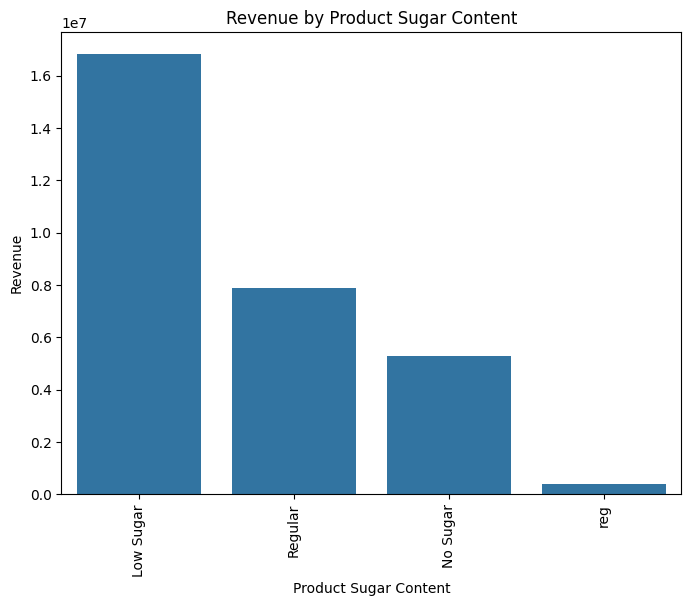

In [85]:
plot_sales_by_category(data, "Product_Sugar_Content")

"Low Sugar" products generated more revenue.

,Store_Location_City_Type,Product_Store_Sales_Total
1,Tier 2,21650696.61
0,Tier 1,6673457.57
2,Tier 3,2030909.72


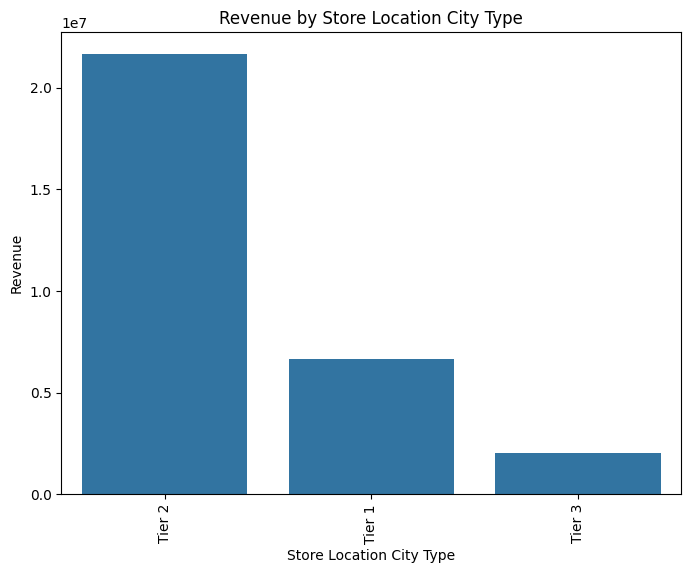

In [86]:
plot_sales_by_category(data, "Store_Location_City_Type")

Product Type: 'Fruits and Vegetables' generated the highest revenue among all product types.
Product Sugar Content: Products with 'Low Sugar' content contributed the most to the total revenue, aligning with their higher sales volume.
Store Performance: Store 'OUT004', identified as a 'Supermarket Type 2', recorded the highest revenue compared to other store IDs and types.
Store Size: Medium-sized stores were the highest revenue generators.
Store Location: Stores located in Tier 2 cities produced the most revenue.

# **Data Preprocessing**

Product_Sugar_Content column conatins 4 types - "Low Sugar", "Regular", "No Sugar", "reg". Replace "reg" with "Regular" so fixing it

In [87]:
data["Product_Sugar_Content"].replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [88]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


,Product_Sugar_Content,Product_Store_Sales_Total
0,Low Sugar,16823405.80
2,Regular,8261714.42
1,No Sugar,5269943.68


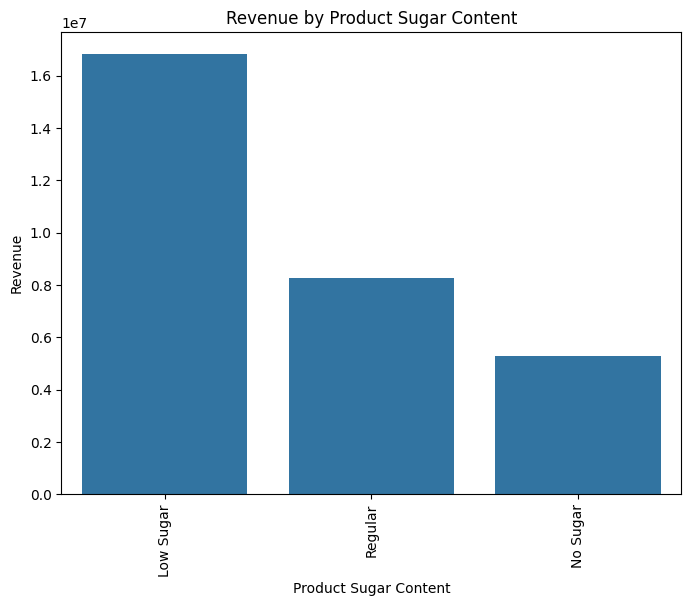

In [163]:
plot_sales_by_category(data, "Product_Sugar_Content")


We see that low sugar products has still high counts and we dont see any 'Reg'

In [89]:
data["Store_Age_Years"] = 2026 - data.Store_Establishment_Year

In [90]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28


In [91]:
data["Product_Type"].unique().tolist()

['Frozen Foods',
 'Dairy',
 'Canned',
 'Baking Goods',
 'Health and Hygiene',
 'Snack Foods',
 'Meat',
 'Household',
 'Hard Drinks',
 'Fruits and Vegetables',
 'Breads',
 'Soft Drinks',
 'Breakfast',
 'Others',
 'Starchy Foods',
 'Seafood']

In [92]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [93]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [94]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [95]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables


In [96]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables


In [97]:
data["Product_Id"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8763 entries, 0 to 8762
Series name: Product_Id
Non-Null Count  Dtype 
--------------  ----- 
8763 non-null   object
dtypes: object(1)
memory usage: 68.6+ KB


In [98]:
# Extract the first two characters from the Product_Id column and store it in a new column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


In [99]:
data["Product_Id_char"].value_counts()

,count
Product_Id_char,
FD,6539
NC,1519
DR,705


In [100]:
display(data.loc[data.Product_Id_char == "FD", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "NC", "Product_Type"].unique())
display(data.loc[data.Product_Id_char == "DR", "Product_Type"].unique())

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

array(['Hard Drinks', 'Soft Drinks'], dtype=object)

In [101]:
data[["Product_Type_Category", "Product_Id_char"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_Type_Category  8763 non-null   object
 1   Product_Id_char        8763 non-null   object
dtypes: object(2)
memory usage: 137.1+ KB


In [102]:
columns = ["Product_Type_Category", "Product_Id_char"]
for column in columns:
    data[column] = data[column].astype("category")

In [103]:
data.columns.tolist()

['Product_Id',
 'Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_Type',
 'Product_MRP',
 'Store_Id',
 'Store_Establishment_Year',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [104]:
data = data.drop(["Product_Id", "Store_Id", "Product_Type", "Store_Establishment_Year"], axis=1)

In [105]:
data.columns.tolist()

['Product_Weight',
 'Product_Sugar_Content',
 'Product_Allocated_Area',
 'Product_MRP',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Store_Sales_Total',
 'Store_Age_Years',
 'Product_Type_Category',
 'Product_Id_char']

In [109]:
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].astype("category")


In [110]:
data.describe(include='category').T

,count,unique,top,freq
Product_Sugar_Content,8763,3,Low Sugar,4885
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676
Product_Type_Category,8763,2,Non Perishables,5718
Product_Id_char,8763,3,FD,6539


In [111]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Type_Category,Product_Id_char
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,17,Non Perishables,FD
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,27,Perishables,FD
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,39,Non Perishables,FD
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,39,Non Perishables,FD
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,28,Non Perishables,NC


## Data Preparation for Modelling

In [112]:
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

X.shape, y.shape

((8763, 10), (8763,))

In [113]:
# Split the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True
)

In [114]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

In [115]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["category"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']
Categorical features: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Type_Category', 'Product_Id_char']


In [116]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features)
)

preprocessor


ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age_Years']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Type_Category',
                                  'Product_Id_char'])])

# **Model Building**

## Define functions for Model Evaluation

In [107]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

For this use case, the best 2 to build and tune are usually:

RandomForestRegressor
XGBRegressor
Why these 2 fit best here

The data is tabular, mixed, and likely nonlinear.
Sales are influenced by interactions like price, store type, city tier, and display area.
Both models handle nonlinear relationships much better than simpler models.
They usually perform strongly on structured business datasets like this one.

### Train Model 1, Random Forest

In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline

rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor, rf_estimator)
rf_estimator.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

Evaluate Random Forest

In [118]:
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)

print("Random Forest - Training Performance")
display(rf_estimator_model_train_perf)

print("Random Forest - Test Performance")
display(rf_estimator_model_test_perf)


Random Forest - Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,104.42435,40.092945,0.990363,0.990347,0.014178


Random Forest - Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.997098,112.581453,0.923438,0.923145,0.050312


### Train Model 2, XGBoost

In [119]:
from xgboost import XGBRegressor

xgb_estimator = XGBRegressor(random_state=1, objective="reg:squarederror")
xgb_estimator = make_pipeline(preprocessor, xgb_estimator)
xgb_estimator.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

 Evaluate XGBoost

In [120]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)

print("XGBoost - Training Performance")
display(xgb_estimator_model_train_perf)

print("XGBoost - Test Performance")
display(xgb_estimator_model_test_perf)


XGBoost - Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,118.628943,58.099567,0.987563,0.987542,0.019789


XGBoost - Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.728392,138.777589,0.915627,0.915305,0.056883


# **Model Performance Improvement - Hyperparameter Tuning**

We will tune the two selected models, `RandomForestRegressor` and `XGBRegressor`, to improve generalization performance on the test set.

To keep the search practical, some hyperparameters are tested with 3 values and some with 2 values.


In [121]:
# Hyperparameter tuning for Random Forest

rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor, rf_tuned)

rf_params = {
    "randomforestregressor__n_estimators": [120, 180, 260],
    "randomforestregressor__max_depth": [8, 14, None],
    "randomforestregressor__min_samples_split": [2, 6],
    "randomforestregressor__min_samples_leaf": [1, 3],
    "randomforestregressor__max_features": ["sqrt", None],
}

rf_grid = GridSearchCV(
    rf_tuned,
    rf_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)


Best Random Forest Parameters:
{'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': None, 'randomforestregressor__min_samples_leaf': 3, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 260}


Evaluate tuned Random Forest

In [122]:
rf_tuned_model_train_perf = model_performance_regression(rf_best, X_train, y_train)
rf_tuned_model_test_perf = model_performance_regression(rf_best, X_test, y_test)

print("Tuned Random Forest - Training Performance")
display(rf_tuned_model_train_perf)

print("Tuned Random Forest - Test Performance")
display(rf_tuned_model_test_perf)


Tuned Random Forest - Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,194.956772,69.474898,0.966409,0.966354,0.024479


Tuned Random Forest - Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,290.117942,108.570931,0.926449,0.926168,0.049677


 Hyperparameter tuning for XGBoost



In [123]:
# Hyperparameter tuning for XGBoost

xgb_tuned = XGBRegressor(
    random_state=1,
    objective="reg:squarederror"
)
xgb_tuned = make_pipeline(preprocessor, xgb_tuned)

xgb_params = {
    "xgbregressor__n_estimators": [200, 320],
    "xgbregressor__max_depth": [3, 5, 7],
    "xgbregressor__learning_rate": [0.03, 0.08],
    "xgbregressor__subsample": [0.8, 1.0],
    "xgbregressor__colsample_bytree": [0.75, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_tuned,
    xgb_params,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)


Best XGBoost Parameters:
{'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__learning_rate': 0.03, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 200, 'xgbregressor__subsample': 0.8}


Evaluate tuned XGBoost

In [124]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_best, X_train, y_train)
xgb_tuned_model_test_perf = model_performance_regression(xgb_best, X_test, y_test)

print("Tuned XGBoost - Training Performance")
display(xgb_tuned_model_train_perf)

print("Tuned XGBoost - Test Performance")
display(xgb_tuned_model_test_perf)


Tuned XGBoost - Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,196.586137,74.851523,0.965845,0.965789,0.025651


Tuned XGBoost - Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,290.490933,111.333806,0.92626,0.925978,0.048834


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [125]:
models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = ["RF", "XGB", "Tuned RF", "Tuned XGB"]
print("Training performance comparison")
display(models_train_comp_df)

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = ["RF", "XGB", "Tuned RF", "Tuned XGB"]
print("Test performance comparison")
display(models_test_comp_df)


Training performance comparison


,RF,XGB,Tuned RF,Tuned XGB
RMSE,104.424350,118.628943,194.956772,196.586137
MAE,40.092945,58.099567,69.474898,74.851523
R-squared,0.990363,0.987563,0.966409,0.965845
Adj. R-squared,0.990347,0.987542,0.966354,0.965789
MAPE,0.014178,0.019789,0.024479,0.025651


Test performance comparison


,RF,XGB,Tuned RF,Tuned XGB
RMSE,295.997098,310.728392,290.117942,290.490933
MAE,112.581453,138.777589,108.570931,111.333806
R-squared,0.923438,0.915627,0.926449,0.926260
Adj. R-squared,0.923145,0.915305,0.926168,0.925978
MAPE,0.050312,0.056883,0.049677,0.048834


Among all four models, the tuned Random Forest model was selected as the final model.

It achieved the highest test R-squared value of 0.9264, along with the lowest RMSE of 290.12 and the lowest MAE of 108.57. Although the tuned XGBoost model produced a slightly lower MAPE, the tuned Random Forest delivered the strongest overall test performance while also showing a much smaller train-test gap than the untuned models. This indicates that it generalizes better and is the most suitable model for deployment.


## Serialize the best model

In [126]:
final_model = rf_best


In [127]:
import os
import joblib

backend_sources = "backend_files"
saved_model = "forecast_superkart_sales_model.joblib"

if not os.path.exists(backend_sources):
    os.makedirs(backend_sources)

joblib.dump(final_model, os.path.join(backend_sources, saved_model))
print(f"Model saved at {os.path.join(backend_sources, saved_model)}")


Model saved at backend_files/forecast_superkart_sales_model.joblib


In [128]:
loaded_model = joblib.load(os.path.join(backend_sources, saved_model))
loaded_model


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_features=None, min_samples_leaf=3,
                                       n_estimators=260, random_state=1))])

In [129]:
loaded_model = joblib.load(os.path.join(backend_sources, saved_model))
loaded_model


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category',
                                                   'Product_Id_char'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_features=None, min_samples_leaf=3,
                                       n_estimators=260, random_state=1))])

# **Deployment - Backend**

## Flask Web Framework



The backend will expose the trained machine learning model through a Flask API.

This API will:
- load the serialized final model
- accept product and store details as JSON input
- generate a sales prediction
- return the predicted sales value as a JSON response

Since the model was trained on the processed dataset, the API will expect the same final features used during model training.


In [130]:
backend_sources = "backend_files"

if not os.path.exists(backend_sources):
    os.makedirs(backend_sources)
    print(f"Directory '{backend_sources}' created successfully.")
else:
    print(f"Directory '{backend_sources}' already exists.")


Directory 'backend_files' already exists.


## Create the Flask API Application


In [131]:
%%writefile "{backend_sources}/app.py"

import pandas as pd
import joblib
from flask import Flask, request, jsonify

# Initialize Flask app
app = Flask(__name__)

# Load the serialized final model
model = joblib.load("forecast_superkart_sales_model.joblib")

# Expected input columns based on the final processed training dataset
required_columns = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Store_Age_Years",
    "Product_Type_Category",
    "Product_Id_char",
]

@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "SuperKart Sales Forecast API is running",
        "prediction_endpoint": "/predict"
    })

@app.route("/predict", methods=["POST"])
def predict():
    try:
        payload = request.get_json(silent=True)

        if payload is None:
            return jsonify({"error": "Provide input data in JSON format."}), 400

        records = payload if isinstance(payload, list) else [payload]
        input_df = pd.DataFrame(records)

        missing_columns = [col for col in required_columns if col not in input_df.columns]
        if missing_columns:
            return jsonify({"error": f"Missing columns: {missing_columns}"}), 400

        input_df = input_df[required_columns]

        prediction = model.predict(input_df)

        return jsonify({
            "predictions": [round(float(value), 2) for value in prediction]
        })

    except Exception as e:
        return jsonify({"error": f"Prediction failed: {str(e)}"}), 500

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=7860)


Writing backend_files/app.py


## Dependencies File

In [138]:
%%writefile "{backend_sources}/requirements.txt"

pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
flask==3.0.3
gunicorn==23.0.0


Overwriting backend_files/requirements.txt


## Dockerfile

In [139]:
%%writefile "{backend_sources}/Dockerfile"

FROM python:3.11-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:app"]


Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

To deploy the backend on Hugging Face:

1. Go to Hugging Face and create a new Space
2. Select **Docker** as the SDK
3. Give the Space an appropriate name, such as `superkart-sales-backend`
4. Keep the Space public or private based on your requirement
5. After creating the Space, note the repository ID in the format:

`your-username/your-space-name`

This repository ID will be used in the upload step below.


In [141]:
backend_repo_id = "hazyn/SuperKart-Backend"
print("Update backend_repo_id before uploading files.")


Update backend_repo_id before uploading files.


## Uploading Files to Hugging Face Space (Docker Space)




In [142]:
# Save the final selected model into backend_files if not already saved there
joblib.dump(final_model, os.path.join(backend_sources, "forecast_superkart_sales_model.joblib"))

print("Final model saved inside backend_files.")
print(os.listdir(backend_sources))


Final model saved inside backend_files.
['app.py', 'forecast_superkart_sales_model.joblib', 'requirements.txt', 'Dockerfile']


In [143]:
from huggingface_hub import login
import os


# Option 2:  using Colab secrets
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

hf_token = os.getenv("HF_TOKEN")

if hf_token:
    login(token=hf_token)
    print("Logged in to Hugging Face successfully.")
else:
    print("HF_TOKEN is not set.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face successfully.


In [144]:
api = HfApi()

api.upload_folder(
    folder_path=backend_sources,
    repo_id=backend_repo_id,
    repo_type="space",
)

print("Backend files uploaded successfully.")


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...recast_superkart_sales_model.joblib:  59%|#####9    | 23.9MB / 40.3MB            

Backend files uploaded successfully.


In [149]:
import requests

base_url = "https://hazyn-superkart-backend.hf.space"
predict_url = f"{base_url}/predict"

print("Root check:")
root_response = requests.get(base_url)
print(root_response.status_code)
print(root_response.text)

sample_payload = {
    "Product_Weight": 12.66,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.027,
    "Product_MRP": 117.08,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type2",
    "Store_Age_Years": 17,
    "Product_Type_Category": "Non Perishables",
    "Product_Id_char": "FD"
}

print("\nPredict check:")
pred_response = requests.post(predict_url, json=sample_payload)
print(pred_response.status_code)
print(pred_response.text)



Root check:
200
{"message":"SuperKart Sales Forecast API is running","prediction_endpoint":"/predict"}


Predict check:
200
{"predictions":[2898.19]}



The backend API was successfully deployed on Hugging Face as a Docker Space.

The root endpoint confirmed that the Flask service was active, and the `/predict` endpoint successfully returned sales predictions for sample input data. This verifies that the trained model was correctly serialized, loaded in the backend application, and made accessible through a REST API.


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

The frontend application will provide an interactive user interface for generating sales predictions.

This Streamlit app will:
- collect the required product and store inputs from the user
- send those inputs to the deployed backend API
- receive the predicted sales value
- display the result in a clean and interactive format


In [255]:
frontend_sources = "frontend_files"

if not os.path.exists(frontend_sources):
    os.makedirs(frontend_sources)
    print(f"Directory '{frontend_sources}' created successfully.")
else:
    print(f"Directory '{frontend_sources}' already exists.")


Directory 'frontend_files' already exists.


In [256]:
%%writefile frontend_files/app.py
import streamlit as st
import requests

# --- Page Config ---
st.set_page_config(page_title="SuperKart Analytics Pro", page_icon="📈", layout="centered")

# --- Custom Styling ---
st.markdown("""
    <style>
    .input-card { background: #f8fafc; padding: 1.5rem; border-radius: 10px; border: 1px solid #e2e8f0; }
    .stNumberInput, .stSelectbox { margin-bottom: 1rem; }
    .header-text { text-align: center; color: #1e293b; margin-bottom: 2rem; }
    </style>
""", unsafe_allow_html=True)

st.markdown("<h1 class='header-text'>📈 SuperKart Sales Dashboard</h1>", unsafe_allow_html=True)

# --- Input Sections ---
col1, col2 = st.columns(2)

with col1:
    st.markdown("### 📦 Product Details")
    with st.container(border=True):
        Product_Weight = st.number_input("Product Weight (kg)", 0.0, 50.0, 12.66, help="Weight of the item in kg")
        Product_MRP = st.number_input("Maximum Retail Price ($)", 0.0, 500.0, 117.08, help="List price of the product")
        Product_Sugar_Content = st.selectbox("Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        Product_Id_char = st.selectbox("Category Prefix", ["FD", "NC", "DR"], help="FD=Food, NC=Non-Consumable, DR=Drink")
        Product_Type_Category = st.selectbox("Product Type", ["Perishables", "Non Perishables"])
        Product_Allocated_Area = st.number_input("Shelf Area Ratio", 0.0, 1.0, 0.027, format="%.3f", help="Percentage of shelf space allocated")

with col2:
    st.markdown("### 🏪 Store Context")
    with st.container(border=True):
        Store_Type = st.selectbox("Store Model", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
        Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
        Store_Location_City_Type = st.selectbox("City Tier", ["Tier 1", "Tier 2", "Tier 3"])
        Store_Age_Years = st.slider("Store Age (Years)", 0, 40, 17, help="How many years the store has been operating")

# --- Prediction Action ---
if st.button("🚀 GENERATE FORECAST", type="primary", use_container_width=True):
    payload = {
        "Product_Weight": Product_Weight, "Product_Sugar_Content": Product_Sugar_Content,
        "Product_Allocated_Area": Product_Allocated_Area, "Product_MRP": Product_MRP,
        "Store_Size": Store_Size, "Store_Location_City_Type": Store_Location_City_Type,
        "Store_Type": Store_Type, "Store_Age_Years": Store_Age_Years,
        "Product_Type_Category": Product_Type_Category, "Product_Id_char": Product_Id_char
    }

    with st.spinner("Analyzing market patterns..."):
        try:
            response = requests.post("https://hazyn-superkart-backend.hf.space/predict", json=payload, timeout=20)
            if response.status_code == 200:
                val = response.json()["predictions"][0]

                # Result Display
                st.divider()
                st.markdown(f"""
                    <div style="text-align: center; padding: 2rem; background: #ecfdf5; border-radius: 15px;">
                        <h3 style="color: #065f46;">PROJECTED WEEKLY SALES</h3>
                        <h1 style="font-size: 4rem; color: #059669;">${val:,.2f}</h1>
                    </div>
                """, unsafe_allow_html=True)
                st.balloons()
            else:
                st.error(f"Backend Error: {response.status_code}")
        except Exception:
            st.error("Could not reach the backend service.")

Overwriting frontend_files/app.py


## Dependencies File

In [257]:
%%writefile "{frontend_sources}/requirements.txt"

streamlit==1.37.1
requests==2.32.4


Overwriting frontend_files/requirements.txt


## DockerFile

In [258]:
%%writefile "{frontend_sources}/Dockerfile"

FROM python:3.11-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

# Force rebuild
EXPOSE 7860
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false", "--server.headless=true"]

Overwriting frontend_files/Dockerfile


In [259]:
frontend_repo_id = "hazyn/SuperKart-FrontEnd"
print("Update frontend_repo_id before uploading files.")


Update frontend_repo_id before uploading files.


## Uploading Files to Hugging Face Space (Streamlit Space)

In [260]:
api = HfApi()

api.upload_folder(
    folder_path=frontend_sources,
    repo_id=frontend_repo_id,
    repo_type="space",
)

print("Frontend files uploaded successfully.")


Frontend files uploaded successfully.


# **Actionable Insights and Business Recommendations**

- The tuned Random Forest model delivered the strongest balance between predictive accuracy and generalization, making it the most suitable model for forecasting product-level store sales in this business setting.

- Product price and shelf allocation both appear to influence revenue, which suggests that SuperKart should review pricing strategy together with in-store product placement rather than treating them as separate decisions.

- Tier 2 stores generated the highest overall revenue in the analysis, indicating that these outlets may offer the best near-term opportunity for targeted promotions, inventory prioritization, and category expansion.

- Supermarket formats, especially larger and better-performing store types, contribute more strongly to revenue than smaller formats. This suggests that store type should be factored into sales planning, stocking strategy, and campaign design.

- Low Sugar products generated the highest total revenue in the dataset, which indicates that health-oriented or lower-sugar product lines may deserve stronger promotional visibility and inventory support.

- Product categories such as Fruits and Vegetables and Snack Foods showed strong revenue contribution across stores, so these categories should be monitored closely for replenishment planning and sales optimization.

- The engineered features, including `Store_Age_Years`, `Product_Type_Category`, and `Product_Id_char`, improved the usefulness of the data for modeling. This suggests that business-informed feature design can add real forecasting value beyond raw transactional variables alone.

- The deployed backend API and frontend application make the forecasting system usable beyond analysis. SuperKart can now use the model not only for one-time predictions, but also as a reusable decision-support tool for future pricing, assortment, and inventory planning.

- As a next step, SuperKart should collect more recent sales data and retrain the model periodically so that predictions continue to reflect changing customer demand, store performance, and product trends.
